In [30]:
import pandas as pd
import numpy as np
import os
import json

In [31]:
model_dir = './models_output_json'

In [32]:
def load_data(trace_log_dir):
  trace_log = []
  folder = trace_log_dir
  # the list of the json files
  files = os.listdir(folder)
  # sort the files
  files.sort()

  for file in files:
      # get the date from the file name
      date = file.split('.')[0].split('_')[-1]
      # convert the date from YYYYMMDD to YYYY-MM-DD
      date = '-'.join([date[:4], date[4:6], date[6:]])
      #print('loading data for', date)
      # read the json
      with open(os.path.join(folder, file)) as f:
          data = json.load(f)

      if '_' in data[0]["id"]:
            # Dictionary to store combined weights
            combined_weights = {}
            for stock in data:
                stock_id = stock["id"].split('_')[0]
                weight = stock["weight"]
                if stock_id in combined_weights:
                    combined_weights[stock_id] += weight
                else:
                    combined_weights[stock_id] = weight
            # Convert the dictionary back to a list of dictionaries
            data = [{"id": stock_id, "weight": weight} for stock_id, weight in combined_weights.items()]

      # extract the weights
      trace_log.append(
          {
              "date": date,
              "weights": data
          }
      )
  return trace_log


In [33]:
# enumerate the directories under model_dir
dirs = os.listdir(model_dir)
dirs.sort()

dirs

['NEAT_62',
 'NEAT_62_species-v2-process-opti-fix',
 'finbert-test',
 'human',
 'magnus_model',
 'multi_horizon',
 'multi_horizon_short']

In [34]:
all_model_logs = {}
for dir in dirs:
    trace_log = []
    trace_log_dir = os.path.join(model_dir, dir)
    trace_log = load_data(trace_log_dir)
    all_model_logs[dir] = trace_log

In [35]:
unique_ids = set()
for model, trace_log in all_model_logs.items():
    for entry in trace_log:
        for stock in entry["weights"]:
            # not __CASH__
            if stock["id"] == "__CASH__":
                continue
            unique_ids.add(stock["id"])
            

In [36]:
unique_ids

{'600028.SS',
 '600031.SS',
 '600111.SS',
 '600150.SS',
 '600276.SS',
 '600406.SS',
 '600436.SS',
 '600438.SS',
 '600519.SS',
 '600900.SS',
 '601088.SS',
 '601225.SS',
 '601669.SS',
 'AAL',
 'ABBV',
 'ABNB',
 'ABT',
 'ACGL',
 'ACN',
 'AEP',
 'AIG',
 'AIR.PA',
 'AJG',
 'AKAM',
 'ALB',
 'ALGN',
 'ALLE',
 'ALO.PA',
 'AMAT',
 'AMD',
 'AMZN',
 'ANTO.L',
 'AON',
 'APA',
 'APTV',
 'ARE',
 'ARM',
 'AVGO',
 'AXON',
 'AZN.L',
 'AZO',
 'BA',
 'BA.L',
 'BARC.L',
 'BAYN.DE',
 'BDX',
 'BEI.DE',
 'BEZ.L',
 'BIIB',
 'BKG.L',
 'BKNG',
 'BLDR',
 'BNR.DE',
 'BOL.ST',
 'BRBY.L',
 'BRO',
 'BX',
 'CAH',
 'CAT',
 'CBOE',
 'CBRE',
 'CCH.L',
 'CCI',
 'CDNS',
 'CDW',
 'CE',
 'CI',
 'CL',
 'CMA',
 'CME',
 'CMG',
 'CNA.L',
 'CNC',
 'CNP',
 'CON.DE',
 'COR',
 'COST',
 'CPAY',
 'CPB',
 'CPRT',
 'CRDA.L',
 'CRL',
 'CRM',
 'CTAS',
 'CTRA',
 'CVS',
 'CVX',
 'DCC.L',
 'DECK',
 'DFS',
 'DGE.L',
 'DIS',
 'DLTR',
 'DPLM.L',
 'DTE',
 'DVN',
 'DXCM',
 'ED',
 'EDEN.PA',
 'EL',
 'EL.PA',
 'ELUX-B.ST',
 'ELV',
 'ENPH',
 'ENT.L

In [37]:
unique_ids.add('^GSPC')

In [ ]:
import os, datetime
from pandas_datareader import data as pdr
import yfinance as yfin
stocks_data = None
def reload():
    stocks_data = yfin.download(unique_ids, start='2024-05-14', auto_adjust=False, end=None)['Adj Close']
    # save stock_data, do not download again within 24 hours
    stocks_data.to_csv('stocks_data.csv')
    return stocks_data

#stocks_data = yfin.download(list(unique_ids), start='2024-05-14', end=None)['Close']
if os.path.exists('stocks_data.csv'):
    mtime_dt = datetime.datetime.fromtimestamp(os.path.getmtime('stocks_data.csv'))
    now      = datetime.datetime.now()
    diff_sec = (now - mtime_dt).total_seconds()
    if diff_sec < 4 * 3600:
        stocks_data = pd.read_csv('stocks_data.csv', index_col=0, parse_dates=True)
    else:
        stocks_data = reload()

else:
    stocks_data = reload()


In [39]:
from util import convert, get_currency_pair


for stock_name in list(unique_ids):
  stock_suffix = '.' + stock_name.split('.')[-1]

  exchange_name, needs_inversion, exchange_name_yahoo = get_currency_pair(stock_suffix, 'USD')
  # print(stock_suffix)
  # print(exchange_name)
  if exchange_name is not None:
    print(f'Converting {stock_name} to USD')
    df = stocks_data[[stock_name]]
    if len(df) == 0:
      print(f'No data for {stock_name}')
      continue
    df = df.rename(columns={stock_name: 'Adj Close'})
    df['Volume'] = 0
    df = df.sort_index(ascending=True)
    df = convert(df, exchange_name, needs_inversion, exchange_name_yahoo)
    stocks_data[stock_name] = df['Adj Close']


Converting SKG.L to USD
Converting OCDO.L to USD
Converting GSK.L to USD
Converting HIK.L to USD
Converting EZJ.L to USD
Converting EPIS-B.ST to USD
Converting LSEG.L to USD
Converting CCH.L to USD
Converting SRT3.DE to USD
Converting SEYE.ST to USD
Converting DCC.L to USD
Converting 600900.SS to USD
Converting SDR.L to USD
Converting 600436.SS to USD
Converting XBRANE.ST to USD
Converting SWED-A.ST to USD
Converting BNR.DE to USD
Converting FSPORT.ST to USD
Converting HSBA.L to USD
Converting EXPN.L to USD
Converting RMV.L to USD
Converting KINV-B.ST to USD
Converting RIO.L to USD
Converting 600406.SS to USD
Converting RHM.DE to USD
Converting SHEL.L to USD
Converting DPLM.L to USD
Converting SGRO.L to USD
Converting BEZ.L to USD
Converting SAP.DE to USD
Converting PRU.L to USD
Converting UU.L to USD
Converting ITRK.L to USD
Converting NG.L to USD
Converting FNM.ST to USD
Converting BOL.ST to USD
Converting PSN.L to USD
Converting AZN.L to USD
Converting DGE.L to USD
Converting LAND.L

In [40]:
duplicates = stocks_data.index.duplicated()
print(stocks_data.index[duplicates])

DatetimeIndex([], dtype='datetime64[ns]', name='Date', freq=None)


In [41]:
import pandas as pd
# Assuming stocks_data is already defined and imported
# Create a range of dates from the minimum to the maximum date in the original DataFrame
stocks_data = stocks_data.sort_index()
all_dates = pd.date_range(start=stocks_data.index.min(), end=stocks_data.index.max(), freq='D')


stocks_data = stocks_data.reindex(all_dates, method='ffill')

In [42]:
stocks_data.index

DatetimeIndex(['2024-05-14', '2024-05-15', '2024-05-16', '2024-05-17',
               '2024-05-18', '2024-05-19', '2024-05-20', '2024-05-21',
               '2024-05-22', '2024-05-23',
               ...
               '2026-06-06', '2026-06-07', '2026-06-08', '2026-06-09',
               '2026-06-10', '2026-06-11', '2026-06-12', '2026-06-13',
               '2026-06-14', '2026-06-15'],
              dtype='datetime64[ns]', length=763, freq='D')

In [43]:
stocks_data.fillna(method='ffill', inplace=True)
sp500_data = stocks_data['^GSPC']
sp500_data


/tmp/ipykernel_2532345/3351786586.py:1: FutureWarning:

DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.



2024-05-14    5246.680176
2024-05-15    5308.149902
2024-05-16    5297.100098
2024-05-17    5303.270020
2024-05-18    5303.270020
                 ...     
2026-06-11    7394.299805
2026-06-12    7431.459961
2026-06-13    7431.459961
2026-06-14    7431.459961
2026-06-15    7431.459961
Freq: D, Name: ^GSPC, Length: 763, dtype: float64

In [44]:
# remove ^GSPC from stocks_data
stocks_data.drop(columns=['^GSPC'], inplace=True)

# remove ^GSPC from unique_ids
unique_ids.remove('^GSPC')

In [45]:
len(unique_ids)

320

In [46]:
sp500_log_return = pd.DataFrame(np.log(sp500_data)).diff()[1:]
log_return = pd.DataFrame(np.log(stocks_data)).diff()[1:]

In [47]:
log_return = log_return.fillna(0)


In [48]:
log_return

,600028.SS,600031.SS,600111.SS,600150.SS,600276.SS,600406.SS,600436.SS,600438.SS,600519.SS,600900.SS,...,WMT,WPP.L,WST,WYNN,XBRANE.ST,XLE,XLK,XLY,XOM,ZTS
2024-05-15,-0.004292,-0.005702,-0.016012,-0.041162,-0.012660,-0.023152,-0.019306,-0.011824,0.000843,-0.001910,...,-0.000501,0.004127,-0.008385,-0.004293,0.041772,0.002239,0.022262,0.001510,0.007704,0.025780
2024-05-16,-0.004626,0.013135,-0.002404,-0.016247,0.000572,-0.023072,-0.002994,-0.000325,0.002768,-0.002233,...,0.067532,0.013186,0.007341,-0.005238,-0.062567,-0.002772,-0.003480,-0.006503,-0.006006,0.002479
2024-05-17,0.005609,0.001041,0.011358,-0.015687,0.000622,0.002317,-0.000045,-0.016576,0.005421,0.013343,...,0.009949,-0.006566,0.004311,-0.000723,-0.031214,0.013891,-0.002216,0.005105,0.014905,0.002013
2024-05-18,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2024-05-19,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-11,0.002090,-0.033993,0.011429,-0.017552,-0.000638,0.007468,0.007208,0.016330,0.002442,0.007197,...,-0.000747,-0.010973,-0.001754,0.023380,0.000961,-0.019590,0.036576,0.024458,-0.027052,0.001352
2026-06-12,0.032372,0.038708,0.040944,0.014228,0.033172,0.018461,0.011709,-0.034309,0.011580,0.015423,...,0.004471,0.030950,-0.004612,-0.004465,0.032364,0.007500,0.008641,0.002576,0.002793,-0.022738
2026-06-13,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2026-06-14,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [49]:
# use the date of the first entry in log_return as the start date
start_date = pd.to_datetime(log_return.index[0])


In [50]:
def update_weight(weights_attr, unique_ids):
  weights = np.zeros(len(unique_ids))
  for asset in weights_attr:
    asset_id = asset['id']
    if asset_id not in unique_ids:
      continue
    asset_weight = asset['weight']
    if 'operation' in asset:
      direction = asset['operation']
      if direction == 'short' and asset_weight > 0:
        asset_weight = -asset_weight
    asset_index = sorted(unique_ids).index(asset_id)
    weights[asset_index] = asset_weight
  return weights

In [51]:

# for each model, check its first log, use the date as its start
# at start the model's asset is same as the sp500, then for each date, calculate the model's daily return and update the model's asset





model_asset_hists = {k: [1] for k in all_model_logs.keys()}
model_cur_weights = {k: np.zeros(len(unique_ids)) for k in all_model_logs.keys()}
model_daily_return_details = {k: [] for k in all_model_logs.keys()}
for date in log_return.index:
    date_str = str(date.date())
    for model, trace_log in all_model_logs.items():
        
        if pd.to_datetime(trace_log[0]['date']) > date:
            # the model is not started, use sp500's return to update the model's asset
            daily_log_return = sp500_log_return.loc[date_str].values[0]
            model_daily_return = daily_log_return
            cur_asset = model_asset_hists[model][-1] * np.exp(model_daily_return)
            model_asset_hists[model].append(cur_asset)
        else:
            weights = model_cur_weights[model]
            for entry in trace_log:
                if entry['date'] == date_str:
                    weights_attr = entry['weights']
                    weights = update_weight(weights_attr, unique_ids)
                    
                    model_cur_weights[model] = weights
                #print(f'Model: {model}, Date: {date_str}, Weights: {weights}')

            daily_log_return = log_return.loc[date_str].values
            model_daily_return = np.dot(weights, daily_log_return)
            cur_asset = model_asset_hists[model][-1] * np.exp(model_daily_return)
            model_asset_hists[model].append(cur_asset)

            daily_return_details = weights * daily_log_return
            model_daily_return_details[model].append(daily_return_details)

            

        


    

In [52]:
len(daily_log_return)

320

In [53]:
model_daily_return_details['NEAT_62']

[array([-0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
        -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -0.00000000e+00,  0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  1.94449013e-04,
         0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -0.00000000e+00, -0.00000000e+00, -0.00000000e+00, -0.00000000e+00,
         0.00000000e+00, -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -4.70027737e-04, -0.00000000e+00, -0.00000000e+00,
        -0.00000000e+00,  0.00000000e+00,  0.00000000e+00, -0.00000000e+00,
        -0.00000000e+00,  0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.0

In [54]:
def show_model_return_details(model_name, unique_ids, past_days=5):
    #  during the most recent past days, find out the tickers with most return and loss

    if model_name not in model_daily_return_details:
        print(f'Model {model_name} not found.')
        return
    
    details = model_daily_return_details[model_name]
    recent_details = details[-past_days:]
    avg_return = np.mean(recent_details, axis=0)
    return_df = pd.DataFrame({
        'Ticker': sorted(unique_ids),
        'Average Return': avg_return
    })
    return_df = return_df.sort_values(by='Average Return', ascending=False)
    # take top 5 and bottom 5
    top5    = return_df.head(5)
    bottom5 = return_df.tail(5)

    # concat them (you can reset_index if you like)
    result = pd.concat([top5, bottom5]).reset_index(drop=True)
    return result
    return return_df

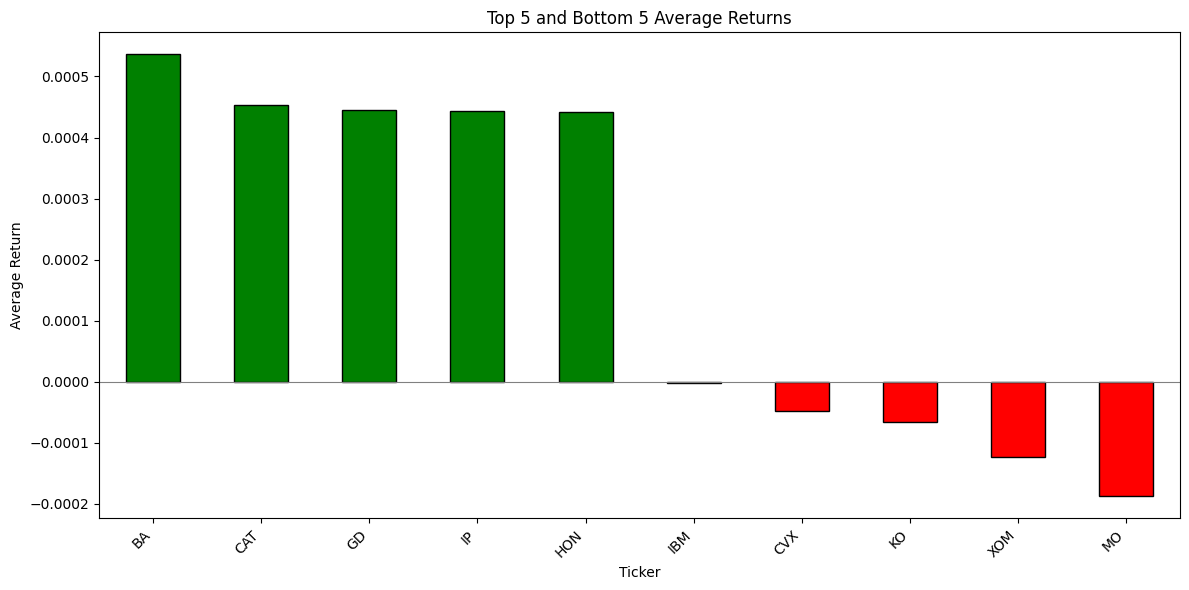

In [55]:
import matplotlib.pyplot as plt

combined_contrib = show_model_return_details('NEAT_62', unique_ids, past_days=5)
  # Create a bar chart
# 2) BAR CHART
# ------------------
# Make the Ticker column the index, so that pandas will
# use it as our x-axis labels
df = combined_contrib.set_index('Ticker')

# Build a color list from the Average Return
colors = ['green' if x >= 0 else 'red' for x in df['Average Return']]

fig, ax = plt.subplots(figsize=(12, 6))
df['Average Return'].plot(
    kind='bar',
    color=colors,
    ax=ax,
    edgecolor='black'
)

ax.axhline(0, color='gray', linewidth=0.8)            # zero line
ax.set_title('Top 5 and Bottom 5 Average Returns')    # give it a title
ax.set_ylabel('Average Return')                       # y-axis label
ax.set_xlabel('Ticker')                               # x-axis label
plt.xticks(rotation=45, ha='right')                   # rotate tick labels
plt.tight_layout()
plt.show()





In [56]:
# append the SP500 asset history into model_asset_hists
model_asset_hists['SP500'] = [1]
for date in sp500_log_return.index:
    date_str = str(date.date())
    daily_log_return = sp500_log_return.loc[date_str].values[0]
    model_daily_return = daily_log_return
    cur_asset = model_asset_hists['SP500'][-1] * np.exp(model_daily_return)
    model_asset_hists['SP500'].append(cur_asset)



In [57]:
def add_vertical_line(fig, date, annotation):
    # draw a line from the bottom (0) to top (1) of the plotting area
    fig.add_shape(
        dict(
            type="line",
            x0=date,
            x1=date,
            y0=0,
            y1=0.9,
            yref="paper",      # span full height
            line=dict(color="blue", width=1),
        )
    )

    # place annotation at the top of the plot
    fig.add_annotation(
        dict(
            x=date,
            y=0.9,
            yref="paper",
            text=annotation,
            showarrow=True,
            arrowhead=2,
            ax=0,
            ay=-40,
            font=dict(size=8),  # shrink the font
        )
    )

In [58]:
# use plotly to plot the curve of the three assets
import plotly.graph_objects as go

fig = go.Figure()
date_list = log_return.index.tolist()
date_list.insert(0, pd.Timestamp('2024-05-14'))

for model, asset_hist in model_asset_hists.items():
    fig.add_trace(go.Scatter(x=date_list, y=asset_hist, mode='lines', name=model))

fig.update_layout(title='Asset Value Over Time', xaxis_title='Date', yaxis_title='Asset Value')

# Example usage of add_vertical_line function
add_vertical_line(fig, '2024-07-20', 'global selectKBest')
add_vertical_line(fig, '2024-10-10', 'multi-horizon')
add_vertical_line(fig, '2024-11-30', 'Short models')
add_vertical_line(fig, '2026-02-10', 'NEAT_62')
fig.show()